<a href="https://colab.research.google.com/github/psr-developer/Machine-Learning-Model-Development-and-Evaluation/blob/main/Week_4_ML_Model_Development.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    auc
)

In [4]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("Dataset Shape:", X.shape)
print("\nFirst 5 Rows:")
print(X.head())

print("\nTarget Distribution:")
print(y.value_counts())

Dataset Shape: (569, 30)

First 5 Rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst 

In [6]:
print("Missing Values:")
print(X.isnull().sum())

print("\nTotal Missing Values:", X.isnull().sum().sum())

Missing Values:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64

Total Missing Values: 0


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [9]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")

Feature scaling completed successfully!


In [11]:
model = LogisticRegression(max_iter=5000)

model.fit(X_train_scaled, y_train)

print("Model training completed successfully!")

Model training completed successfully!


In [12]:
y_pred = model.predict(X_test_scaled)

print("First 10 Predictions:")
print(y_pred[:10])

print("\nActual Values:")
print(y_test.iloc[:10].values)

First 10 Predictions:
[0 1 0 1 0 1 1 0 0 0]

Actual Values:
[0 1 0 1 0 1 1 0 0 0]


In [13]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-Score:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9825
Precision: 0.9861
Recall: 0.9861
F1-Score: 0.9861

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98        42
           1       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



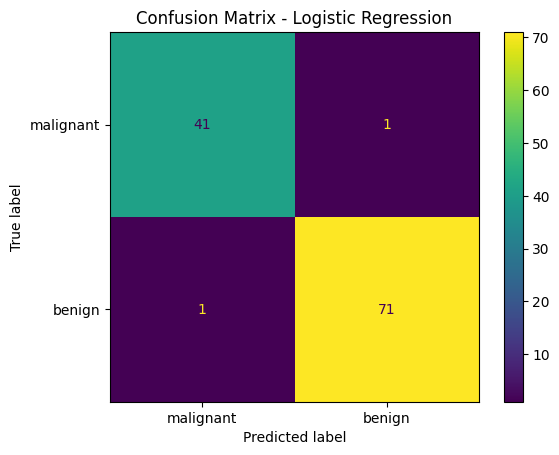

In [14]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

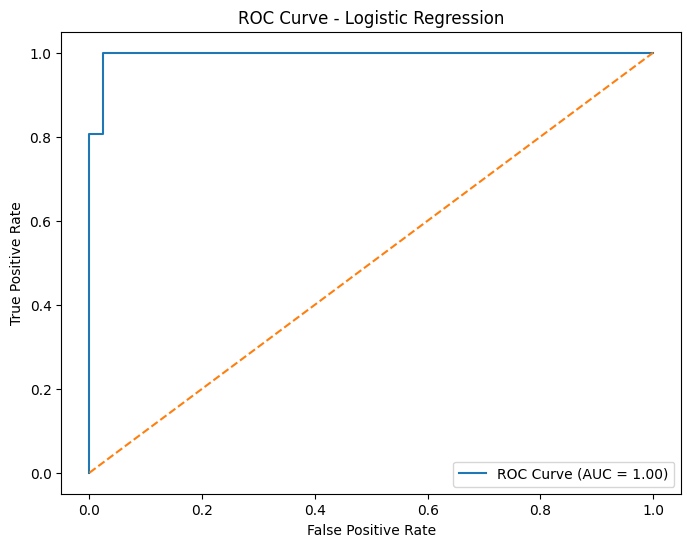

AUC Score: 0.9954


In [15]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()

print("AUC Score:", round(roc_auc, 4))

In [16]:
print("=" * 50)
print("MACHINE LEARNING MODEL FINAL RESULTS")
print("=" * 50)

print("Algorithm: Logistic Regression")
print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])
print("\nAccuracy Score:", round(accuracy, 4))
print("Precision Score:", round(precision, 4))
print("Recall Score:", round(recall, 4))
print("F1 Score:", round(f1, 4))
print("AUC Score:", round(roc_auc, 4))

print("\nModel development and evaluation completed successfully!")

MACHINE LEARNING MODEL FINAL RESULTS
Algorithm: Logistic Regression
Training Samples: 455
Testing Samples: 114

Accuracy Score: 0.9825
Precision Score: 0.9861
Recall Score: 0.9861
F1 Score: 0.9861
AUC Score: 0.9954

Model development and evaluation completed successfully!
